# Heart Failure — Exploratory Data Analysis (EDA)

**Dataset:** Heart Failure Clinical Records (299 patients, 13 features)  
**Source:** Kaggle / UCI — [heart_failure_clinical_records_dataset.csv](https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data)

This notebook performs a comprehensive EDA:
- Dataset overview & statistics
- Missing value analysis
- Distribution plots for all features
- Correlation heatmap
- Class balance analysis
- Feature-wise comparison by DEATH_EVENT
- Outlier detection via boxplots

In [ ]:
# ── Install / upgrade libraries ──────────────────────────────────────────────
!pip install -q pandas numpy matplotlib seaborn scipy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.facecolor': 'white'})

print('Libraries loaded ✔')

Libraries loaded ✔


## 1 · Load Dataset

> **Colab users:** Upload `heart_failure_clinical_records_dataset.csv` or uncomment the direct download cell below.

In [2]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded: 299 rows × 13 columns


In [3]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 2 · Dataset Overview

In [4]:
print('=== Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}\n')

print('=== Data Types ===')
print(df.dtypes.to_string())

print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values ✔')

print('\n=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Shape ===
Rows: 299, Columns: 13

=== Data Types ===
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64

=== Missing Values ===
No missing values ✔

=== Duplicates ===
Duplicate rows: 0


In [5]:
# Descriptive statistics
df.describe().round(2)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00,299.00
mean,60.83,0.43,581.84,0.42,38.08,0.35,263358.03,1.39,136.63,0.65,0.32,130.26,0.32
std,11.89,0.50,970.29,0.49,11.83,0.48,97804.24,1.03,4.41,0.48,0.47,77.61,0.47
min,40.00,0.00,23.00,0.00,14.00,0.00,25100.00,0.50,113.00,0.00,0.00,4.00,0.00
25%,51.00,0.00,116.50,0.00,30.00,0.00,212500.00,0.90,134.00,0.00,0.00,73.00,0.00
50%,60.00,0.00,250.00,0.00,38.00,0.00,262000.00,1.10,137.00,1.00,0.00,115.00,0.00
75%,70.00,1.00,582.00,1.00,45.00,1.00,303500.00,1.40,140.00,1.00,1.00,203.00,1.00
max,95.00,1.00,7861.00,1.00,80.00,1.00,850000.00,9.40,148.00,1.00,1.00,285.00,1.00


## 3 · Feature Glossary

In [6]:
glossary = {
    'age': 'Age of patient (years)',
    'anaemia': 'Decrease of red blood cells (Boolean)',
    'creatinine_phosphokinase': 'Level of CPK enzyme in blood (mcg/L)',
    'diabetes': 'Patient has diabetes (Boolean)',
    'ejection_fraction': '% of blood leaving the heart per contraction',
    'high_blood_pressure': 'Patient has hypertension (Boolean)',
    'platelets': 'Platelets in blood (kiloplatelets/mL)',
    'serum_creatinine': 'Level of serum creatinine in blood (mg/dL)',
    'serum_sodium': 'Level of serum sodium in blood (mEq/L)',
    'sex': 'Gender (0=Female, 1=Male)',
    'smoking': 'Patient smokes (Boolean)',
    'time': 'Follow-up period (days)',
    'DEATH_EVENT': 'Death during follow-up (0=No, 1=Yes)'
}
glossary_df = pd.DataFrame.from_dict(glossary, orient='index',
                                      columns=['Description'])
glossary_df.index.name = 'Feature'
glossary_df

,Description
Feature,
age,Age of patient (years)
anaemia,Decrease of red blood cells (Boolean)
creatinine_phosphokinase,Level of CPK enzyme in blood (mcg/L)
diabetes,Patient has diabetes (Boolean)
ejection_fraction,% of blood leaving the heart per contraction
high_blood_pressure,Patient has hypertension (Boolean)
platelets,Platelets in blood (kiloplatelets/mL)
serum_creatinine,Level of serum creatinine in blood (mg/dL)
serum_sodium,Level of serum sodium in blood (mEq/L)


## 4 · Class Distribution (Target Variable)

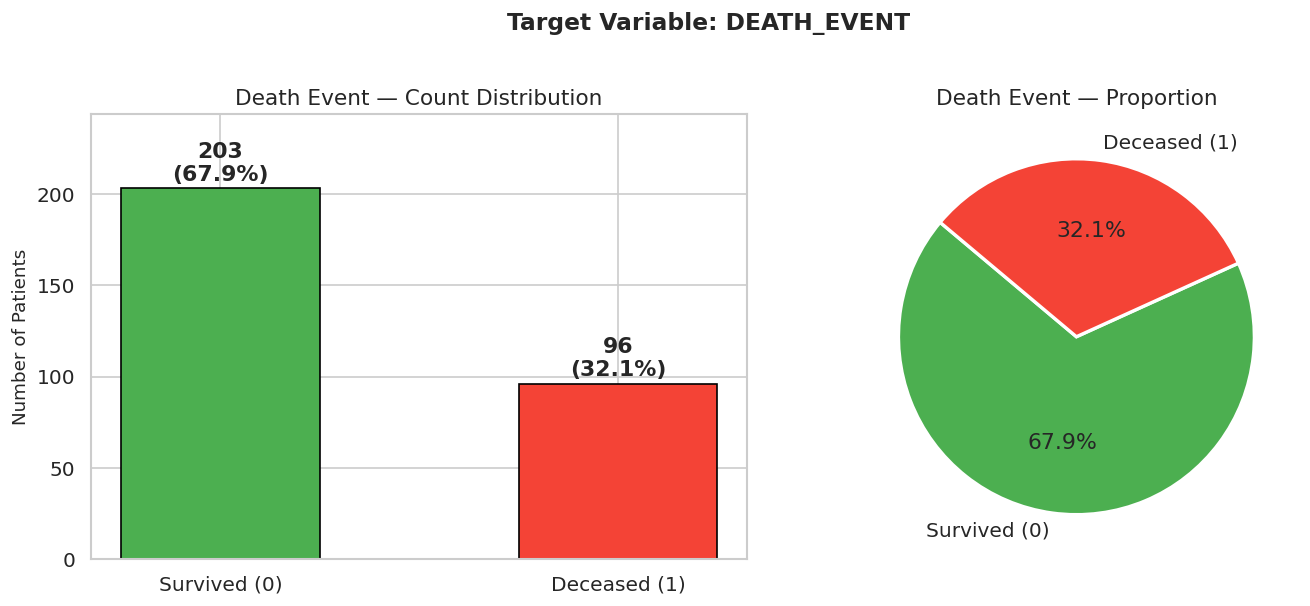

Survival rate : 67.9%
Mortality rate: 32.1%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['DEATH_EVENT'].value_counts()
labels = ['Survived (0)', 'Deceased (1)']
colors = ['#4CAF50', '#F44336']

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='black',
                   width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{count}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Death Event — Count Distribution')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, max(counts.values) * 1.2)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Death Event — Proportion')

plt.suptitle('Target Variable: DEATH_EVENT', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Survival rate : {counts[0]/len(df)*100:.1f}%')
print(f'Mortality rate: {counts[1]/len(df)*100:.1f}%')

## 5 · Univariate Distributions — Continuous Features

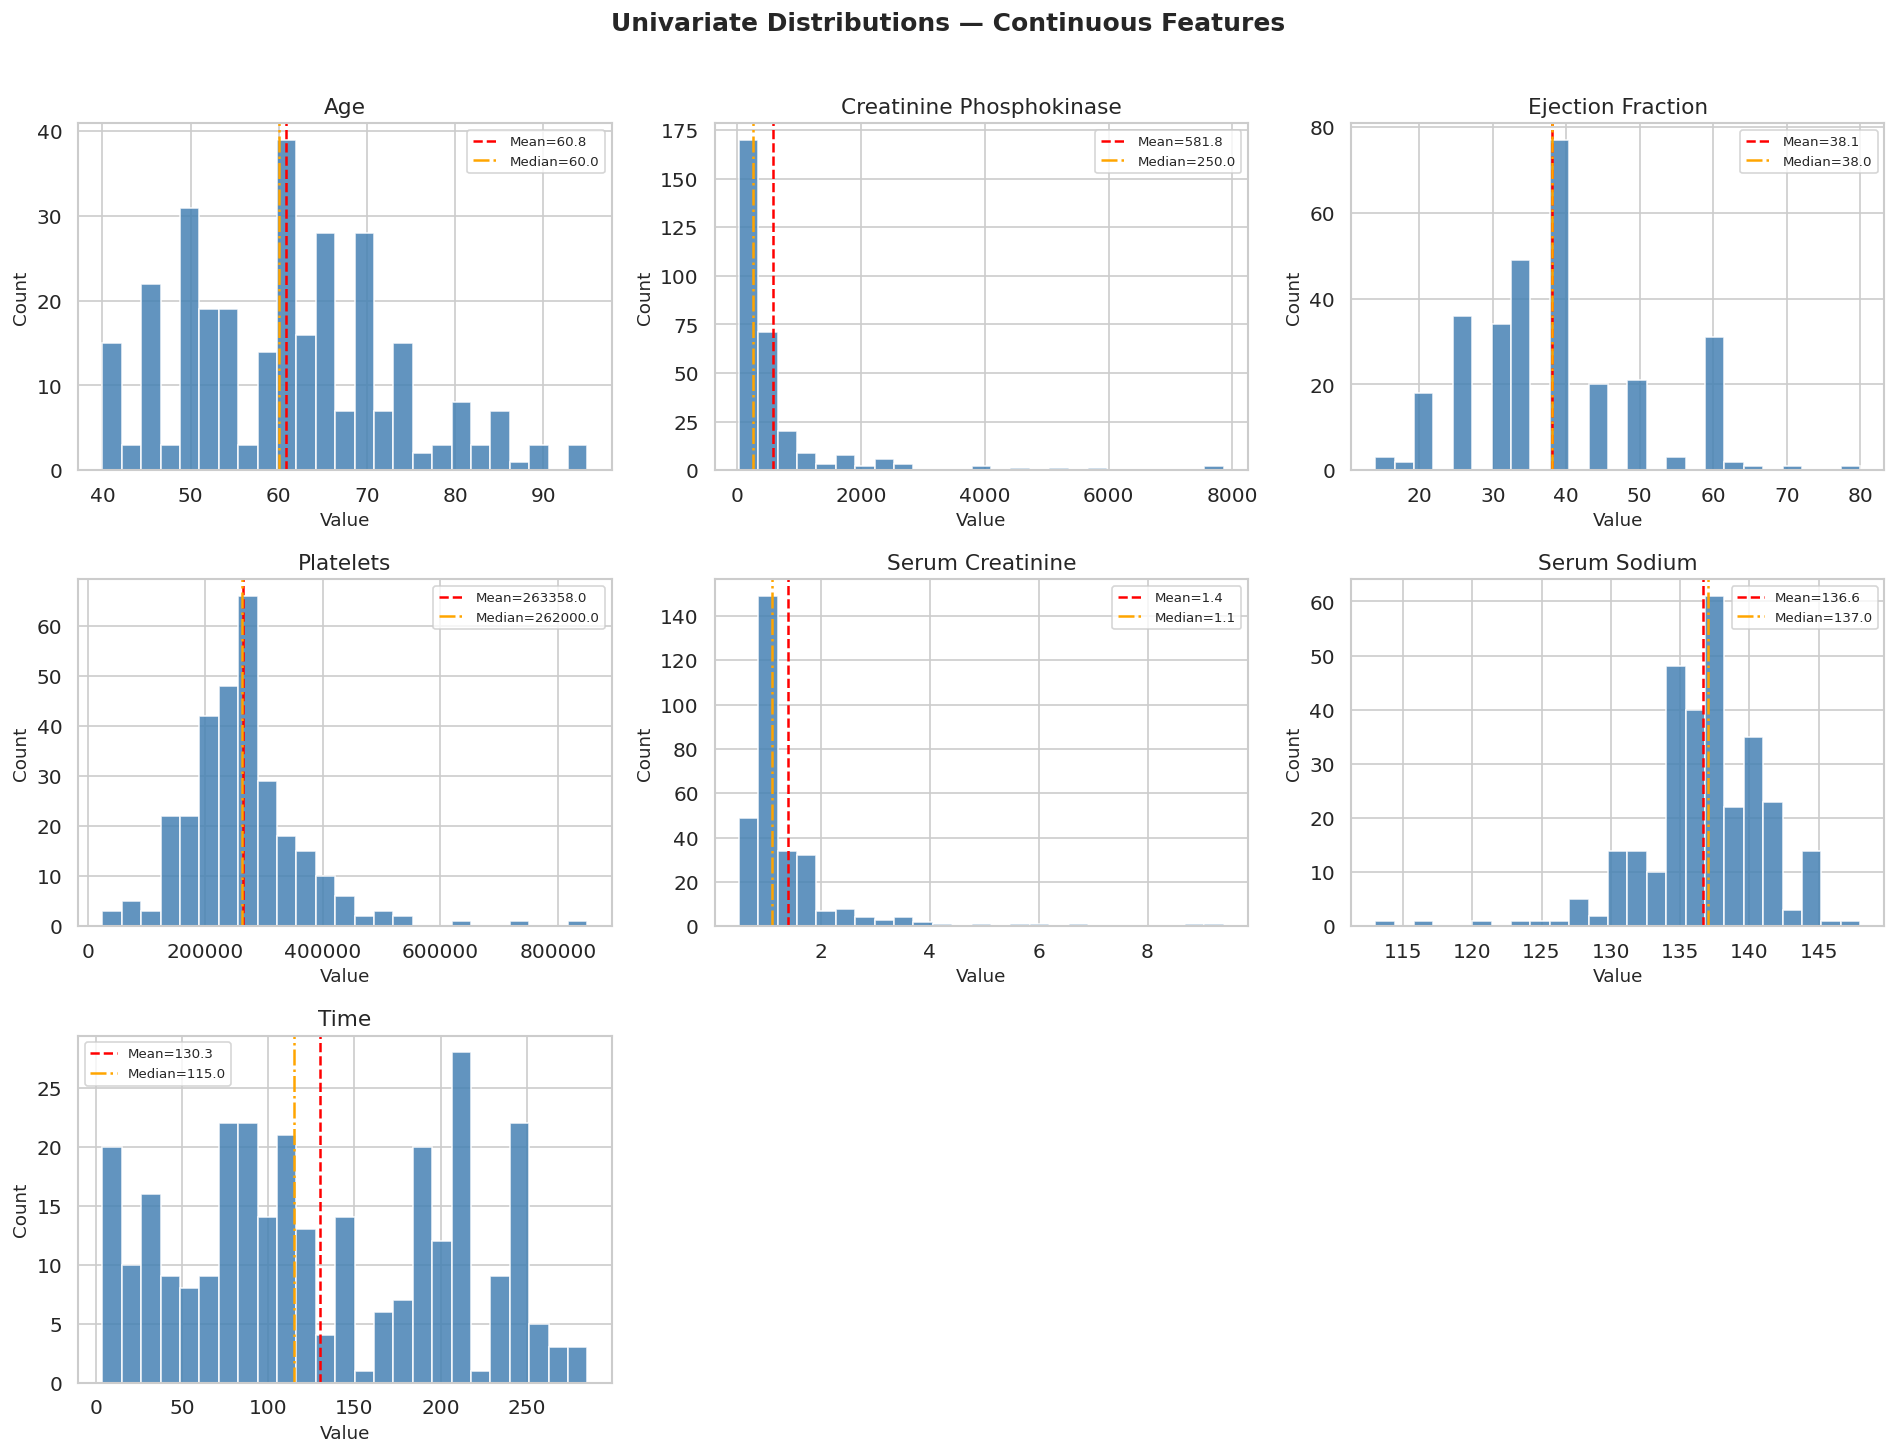

In [8]:
continuous_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                   'platelets', 'serum_creatinine', 'serum_sodium', 'time']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white',
            alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-.',
               linewidth=1.5, label=f'Median={df[col].median():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — Continuous Features',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6 · Univariate Distributions — Categorical / Binary Features

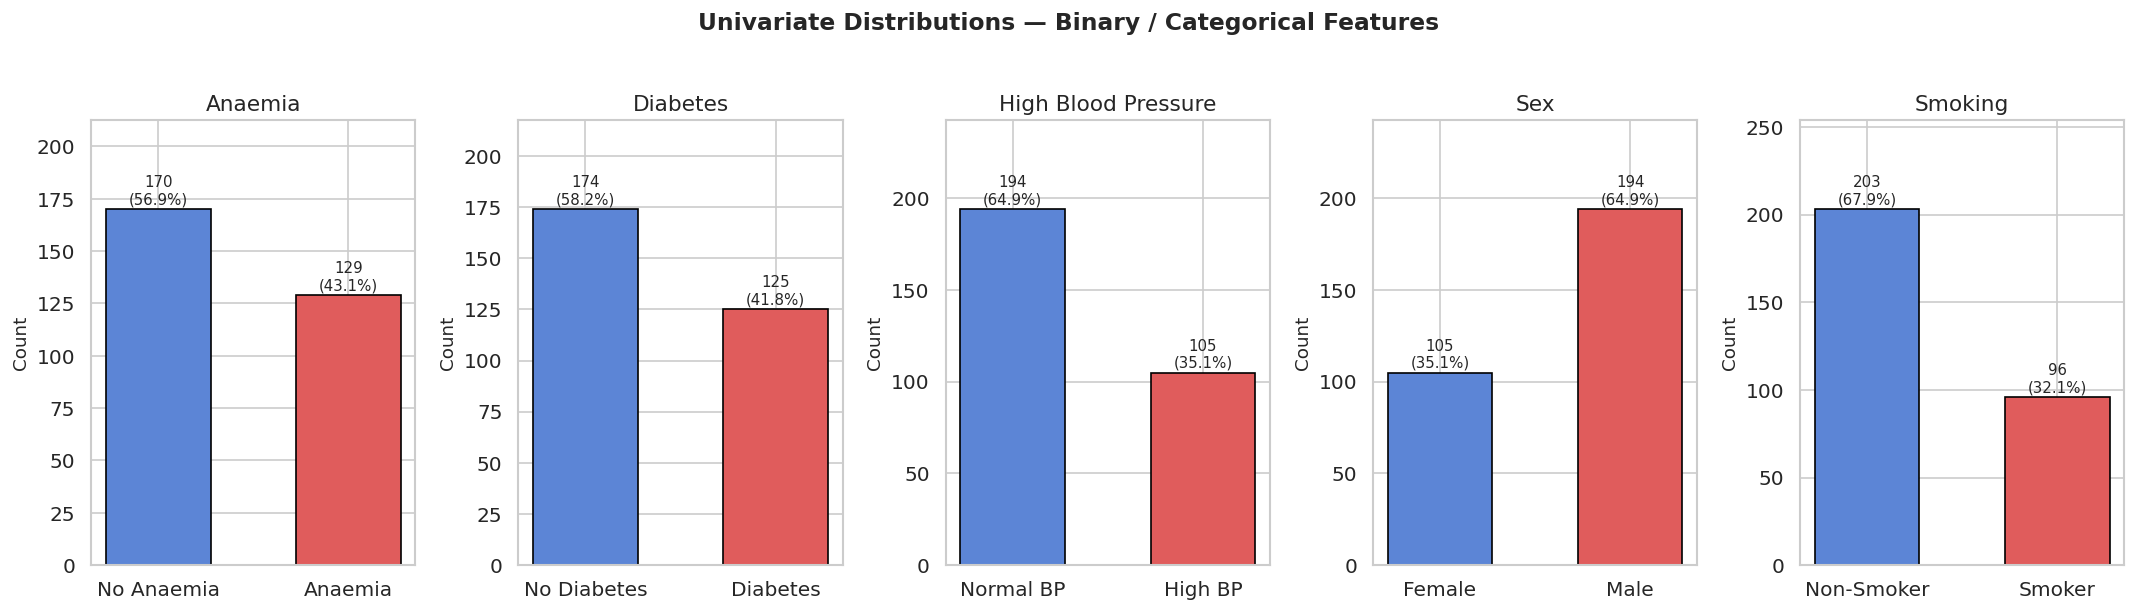

In [9]:
binary_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
binary_labels = {
    'anaemia': ['No Anaemia', 'Anaemia'],
    'diabetes': ['No Diabetes', 'Diabetes'],
    'high_blood_pressure': ['Normal BP', 'High BP'],
    'sex': ['Female', 'Male'],
    'smoking': ['Non-Smoker', 'Smoker']
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
palette = ['#5C85D6', '#E05C5C']

for i, col in enumerate(binary_cols):
    ax = axes[i]
    counts_c = df[col].value_counts().sort_index()
    bars = ax.bar(binary_labels[col], counts_c.values,
                  color=palette, edgecolor='black', width=0.55)
    for bar, v in zip(bars, counts_c.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f'{v}\n({v/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts_c.values) * 1.25)

plt.suptitle('Univariate Distributions — Binary / Categorical Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7 · Bivariate Analysis — Continuous Features vs DEATH_EVENT

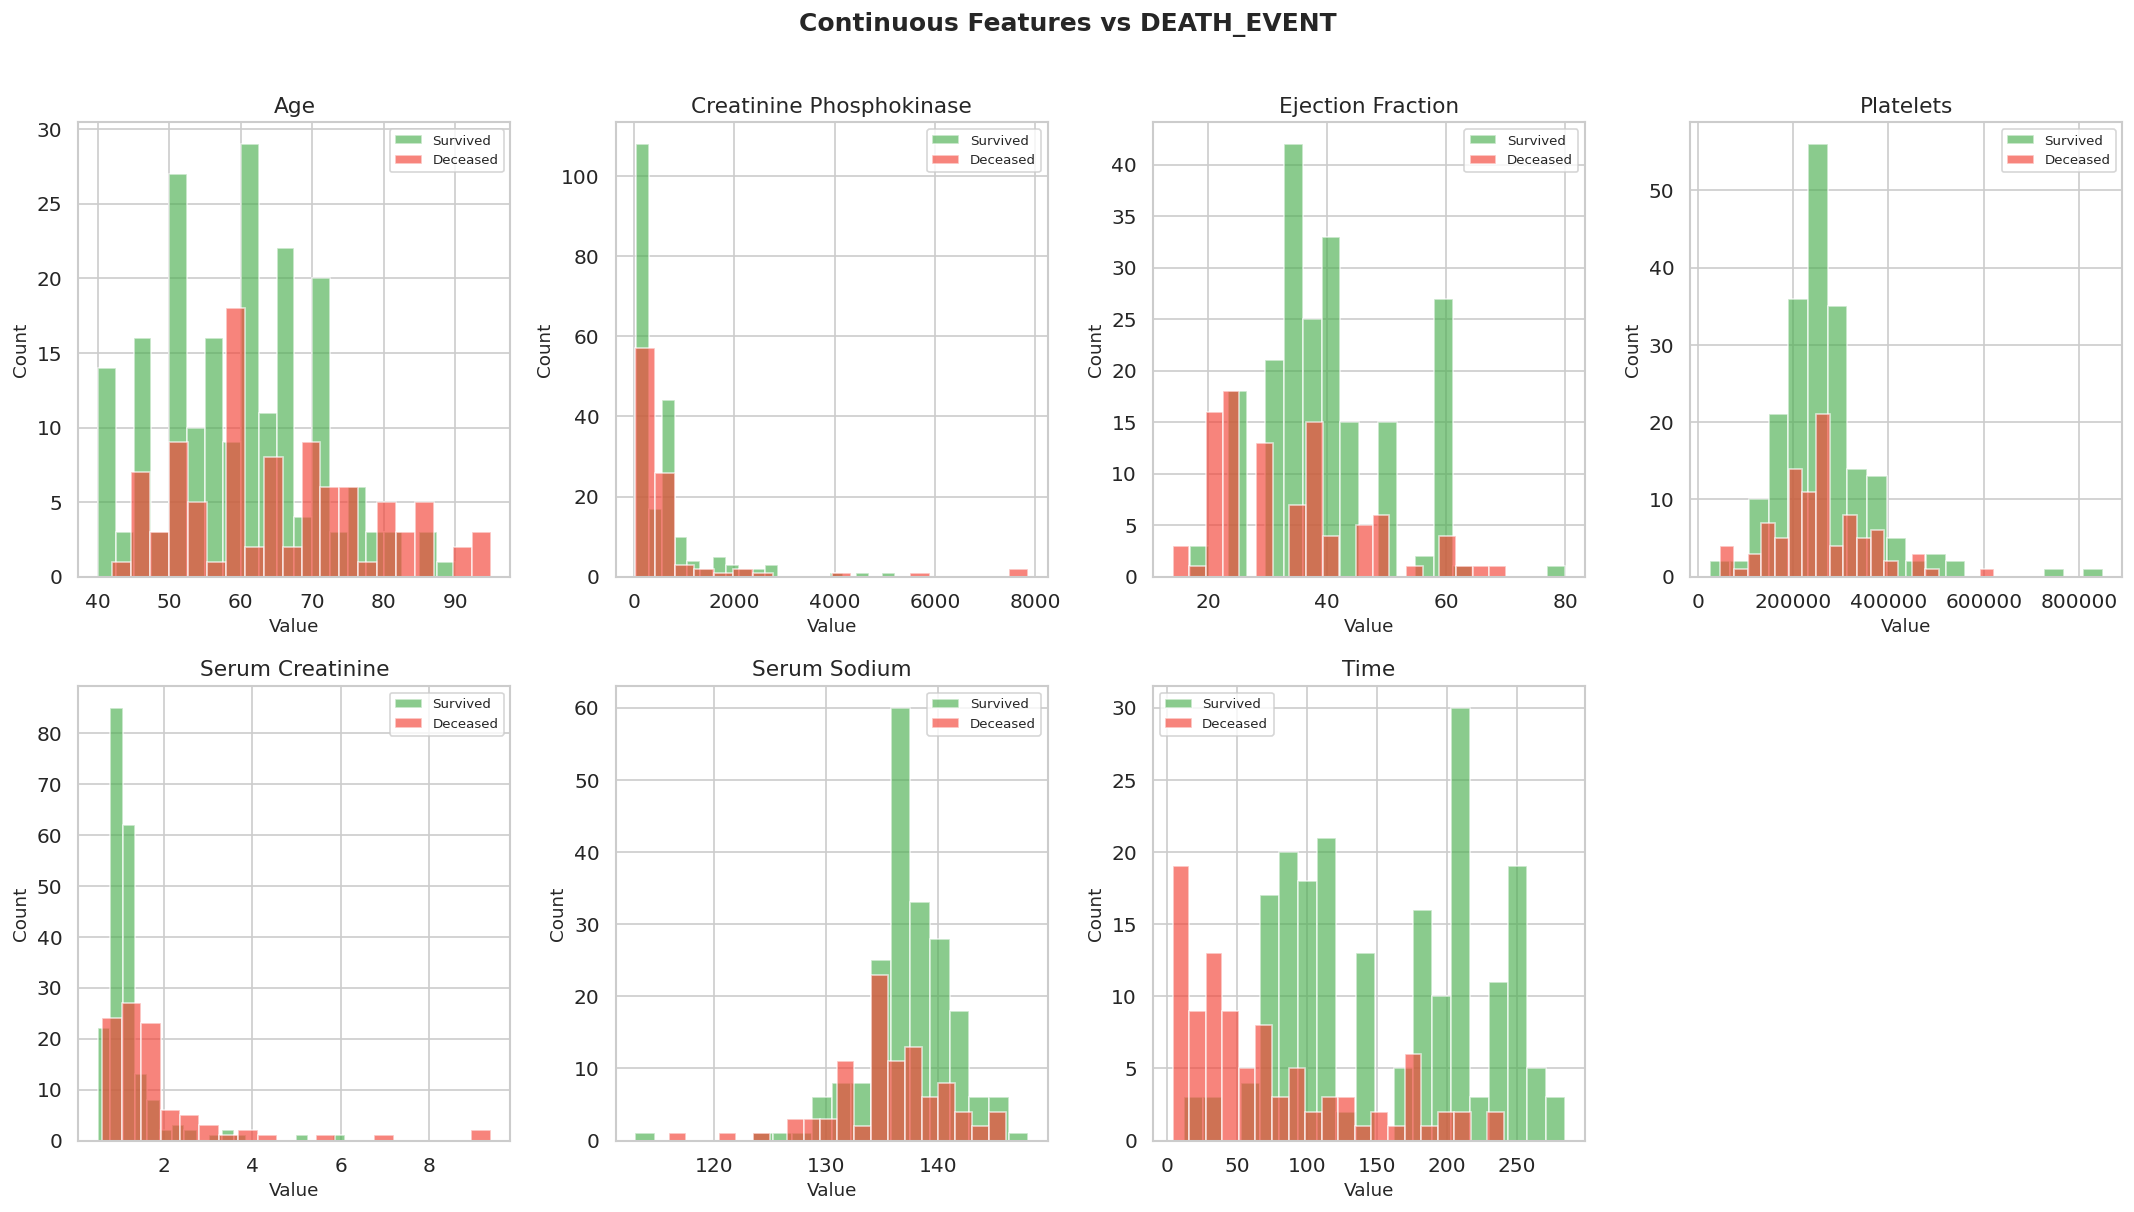

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
palette_de = {0: '#4CAF50', 1: '#F44336'}
hue_labels = {0: 'Survived', 1: 'Deceased'}

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    for de_val, color in palette_de.items():
        subset = df[df['DEATH_EVENT'] == de_val][col]
        ax.hist(subset, bins=20, alpha=0.65, color=color,
                edgecolor='white', label=hue_labels[de_val])
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Continuous Features vs DEATH_EVENT',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

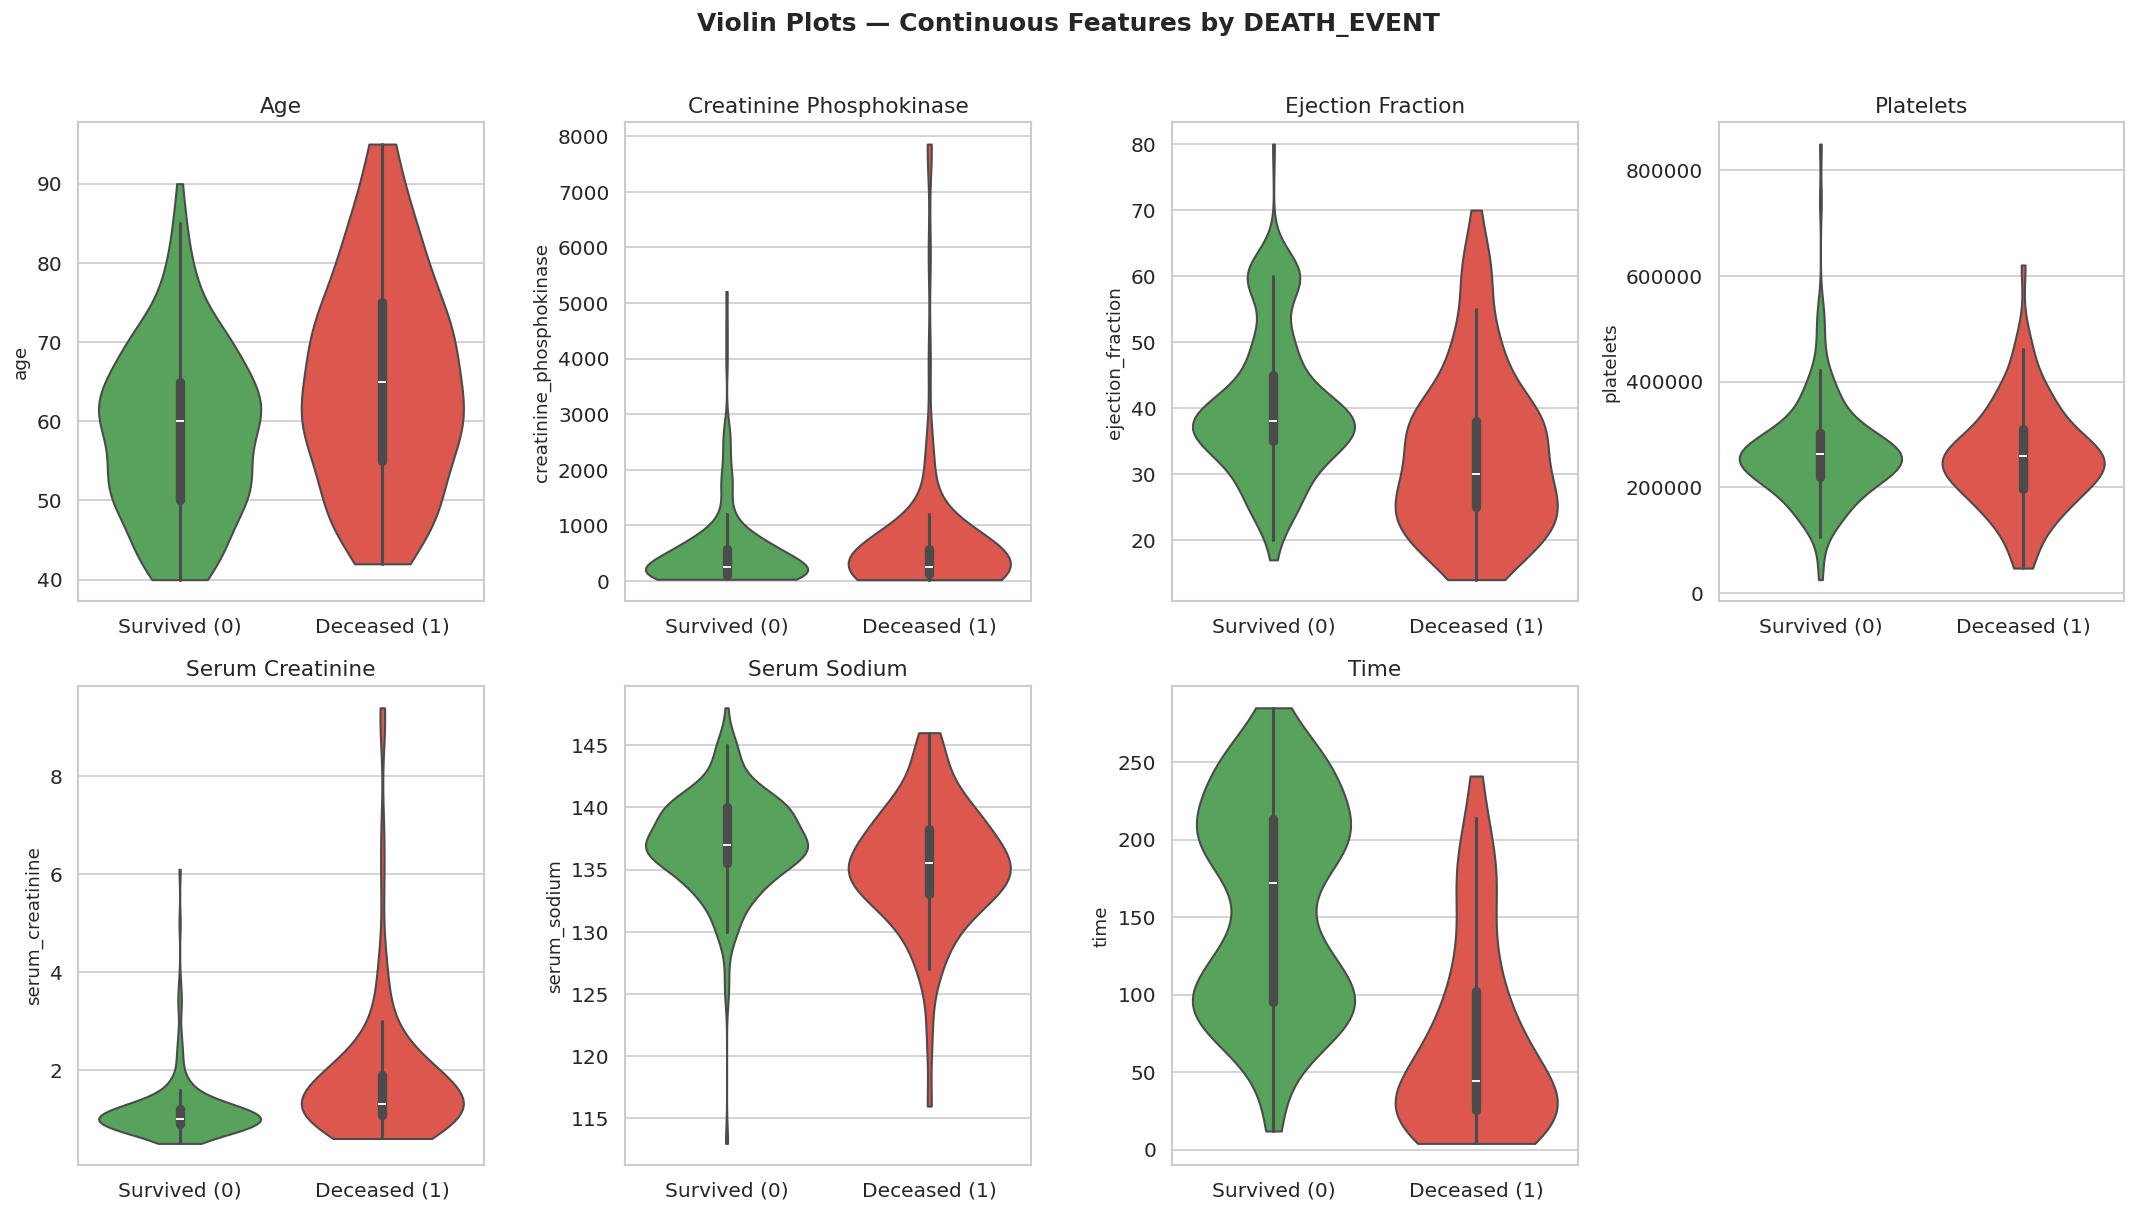

In [11]:
# Violin + Box plots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    sns.violinplot(data=df, x='DEATH_EVENT', y=col, ax=ax,
                   palette=['#4CAF50', '#F44336'],
                   inner='box', cut=0)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xticklabels(['Survived (0)', 'Deceased (1)'])
    ax.set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Violin Plots — Continuous Features by DEATH_EVENT',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8 · Bivariate Analysis — Binary Features vs DEATH_EVENT

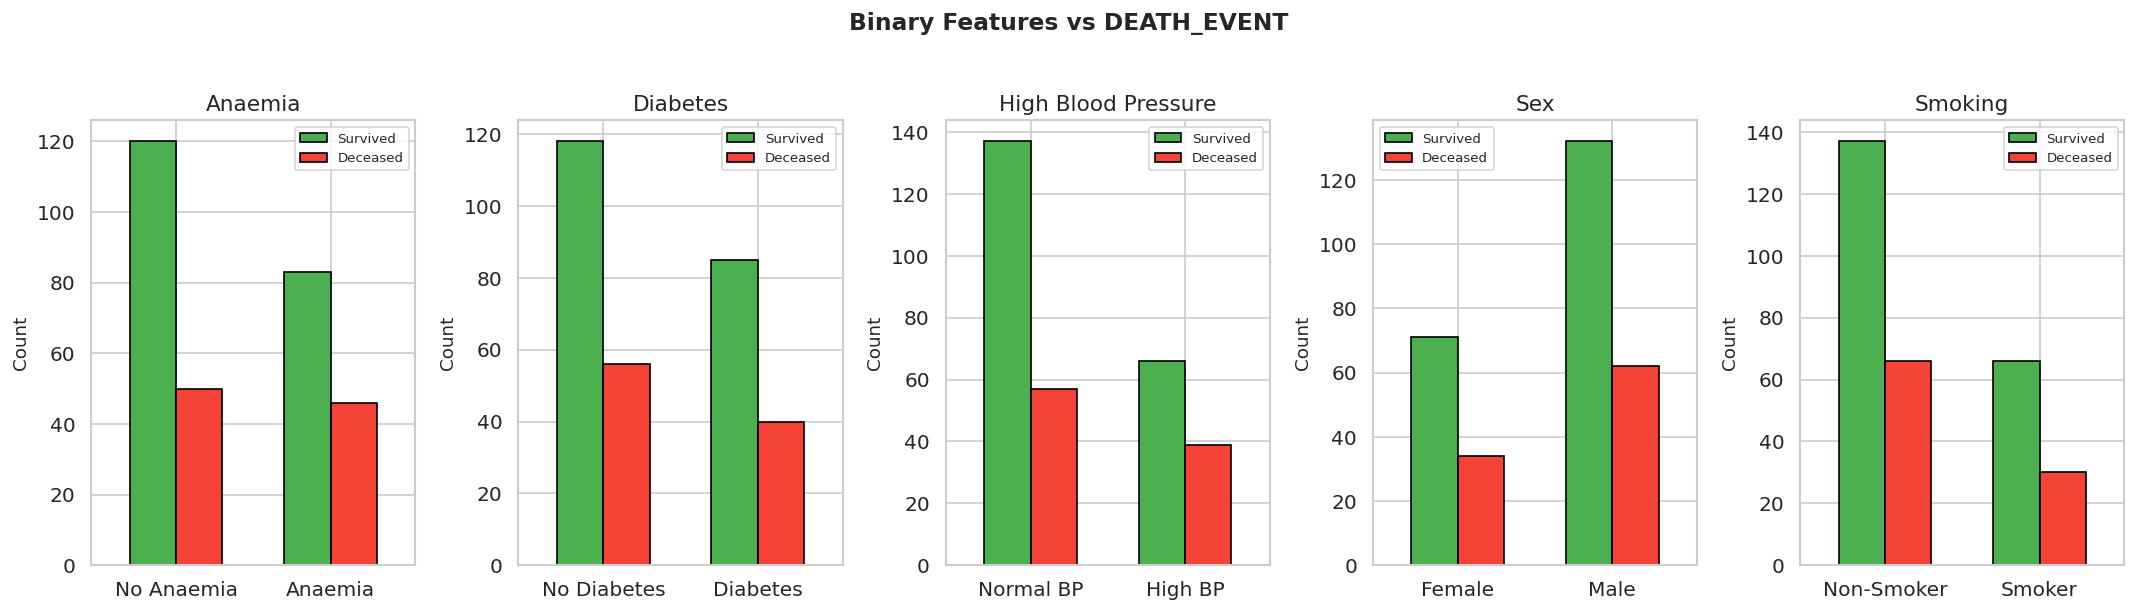

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(binary_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['DEATH_EVENT'])
    ct.columns = ['Survived', 'Deceased']
    ct.index = binary_labels[col]
    ct.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'],
            edgecolor='black', rot=0, width=0.6)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Binary Features vs DEATH_EVENT',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9 · Correlation Heatmap

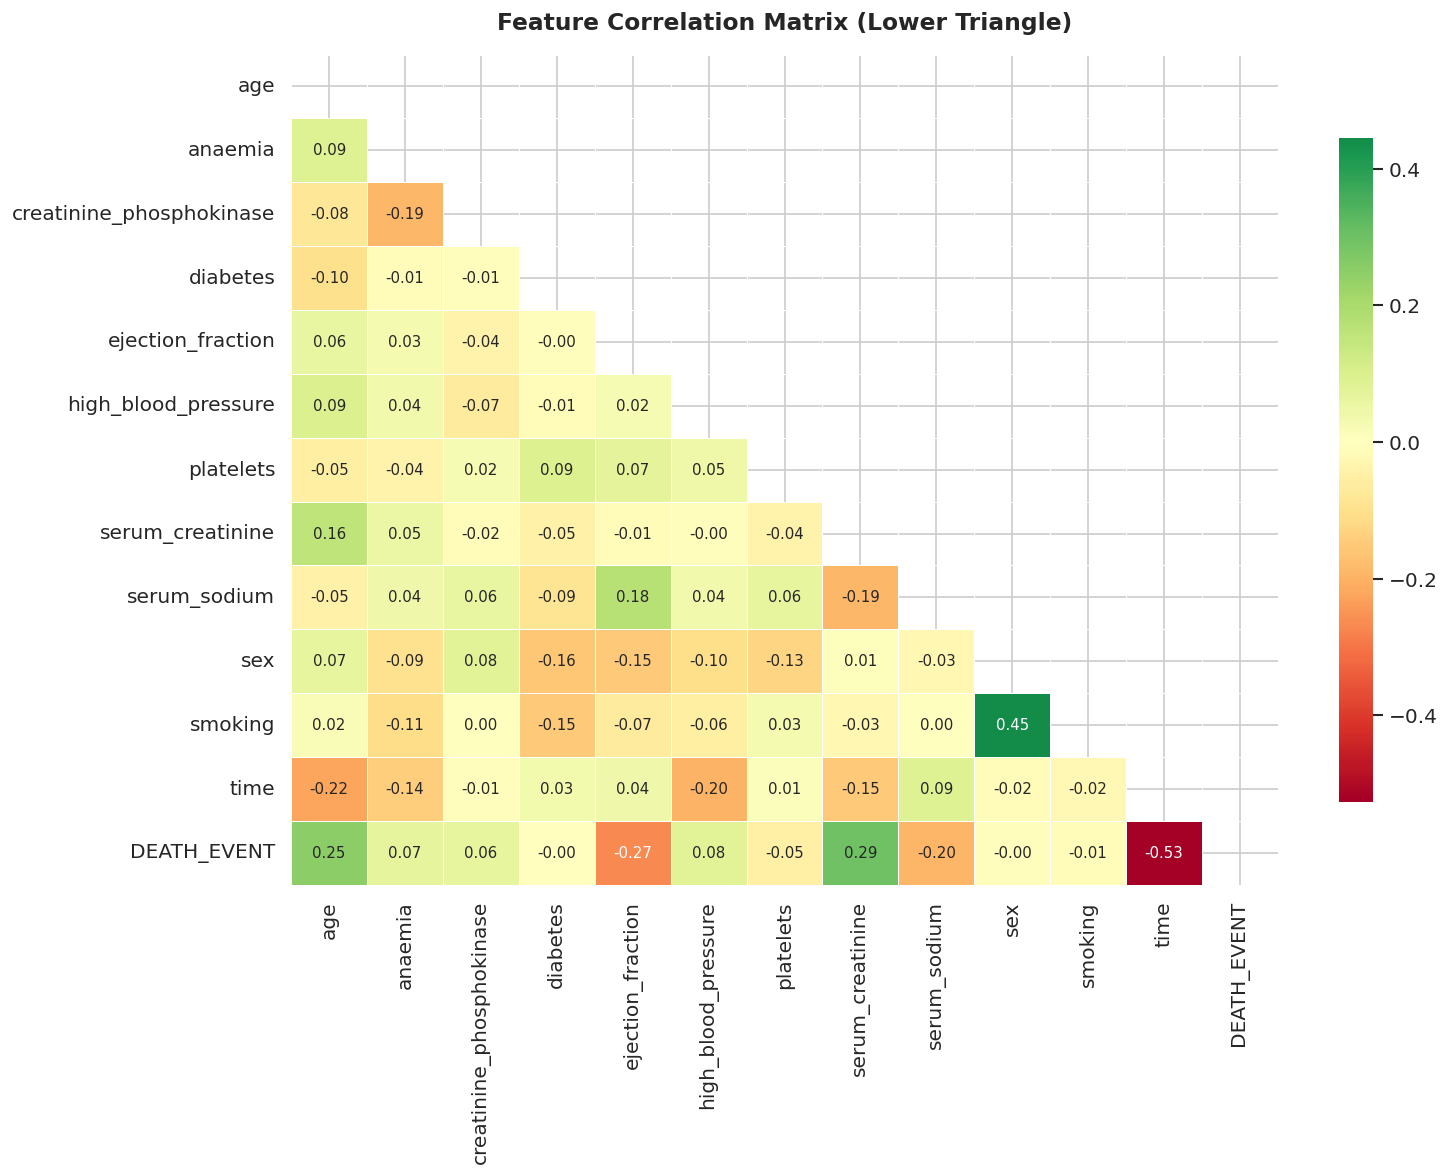


── Correlations with DEATH_EVENT (sorted) ──
time                       -0.527
serum_creatinine            0.294
ejection_fraction          -0.269
age                         0.254
serum_sodium               -0.195
high_blood_pressure         0.079
anaemia                     0.066
creatinine_phosphokinase    0.063
platelets                  -0.049
smoking                    -0.013
sex                        -0.004
diabetes                   -0.002


In [13]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Lower Triangle)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with DEATH_EVENT
print('\n── Correlations with DEATH_EVENT (sorted) ──')
print(corr['DEATH_EVENT'].drop('DEATH_EVENT').sort_values(key=abs,
      ascending=False).round(3).to_string())

## 10 · Outlier Detection — Box Plots

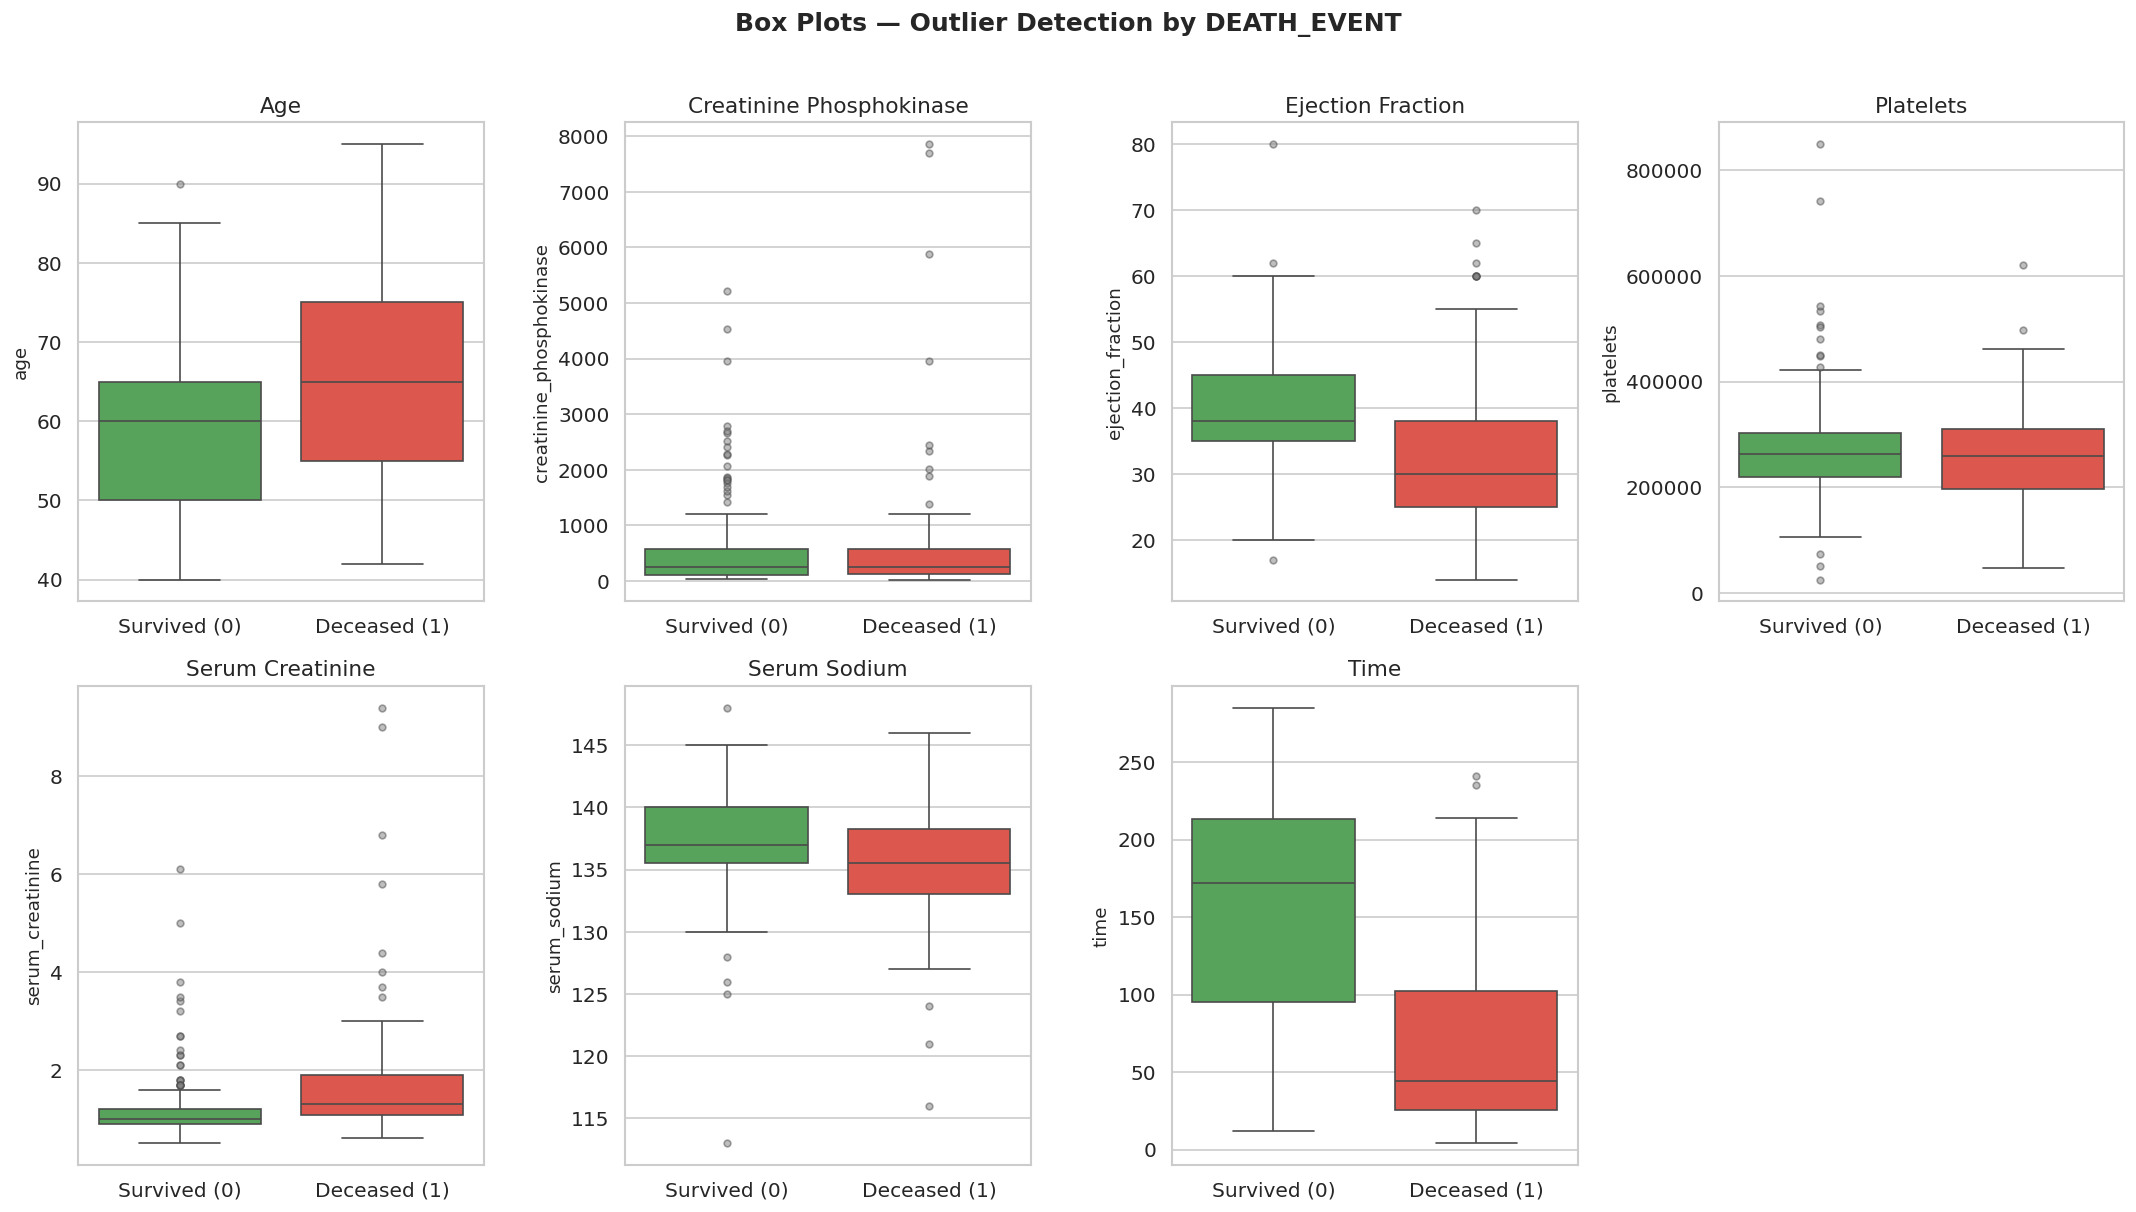

── IQR Outlier Counts ──
  age                           : 0 outliers
  creatinine_phosphokinase      : 29 outliers
  ejection_fraction             : 2 outliers
  platelets                     : 21 outliers
  serum_creatinine              : 29 outliers
  serum_sodium                  : 4 outliers
  time                          : 0 outliers


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='DEATH_EVENT', y=col, ax=ax,
                palette=['#4CAF50', '#F44336'],
                flierprops=dict(marker='o', markerfacecolor='gray',
                                markersize=4, alpha=0.5))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xticklabels(['Survived (0)', 'Deceased (1)'])
    ax.set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Box Plots — Outlier Detection by DEATH_EVENT',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# IQR-based outlier count
print('── IQR Outlier Counts ──')
for col in continuous_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:30s}: {n_out} outliers')

## 11 · Pairplot — Key Features

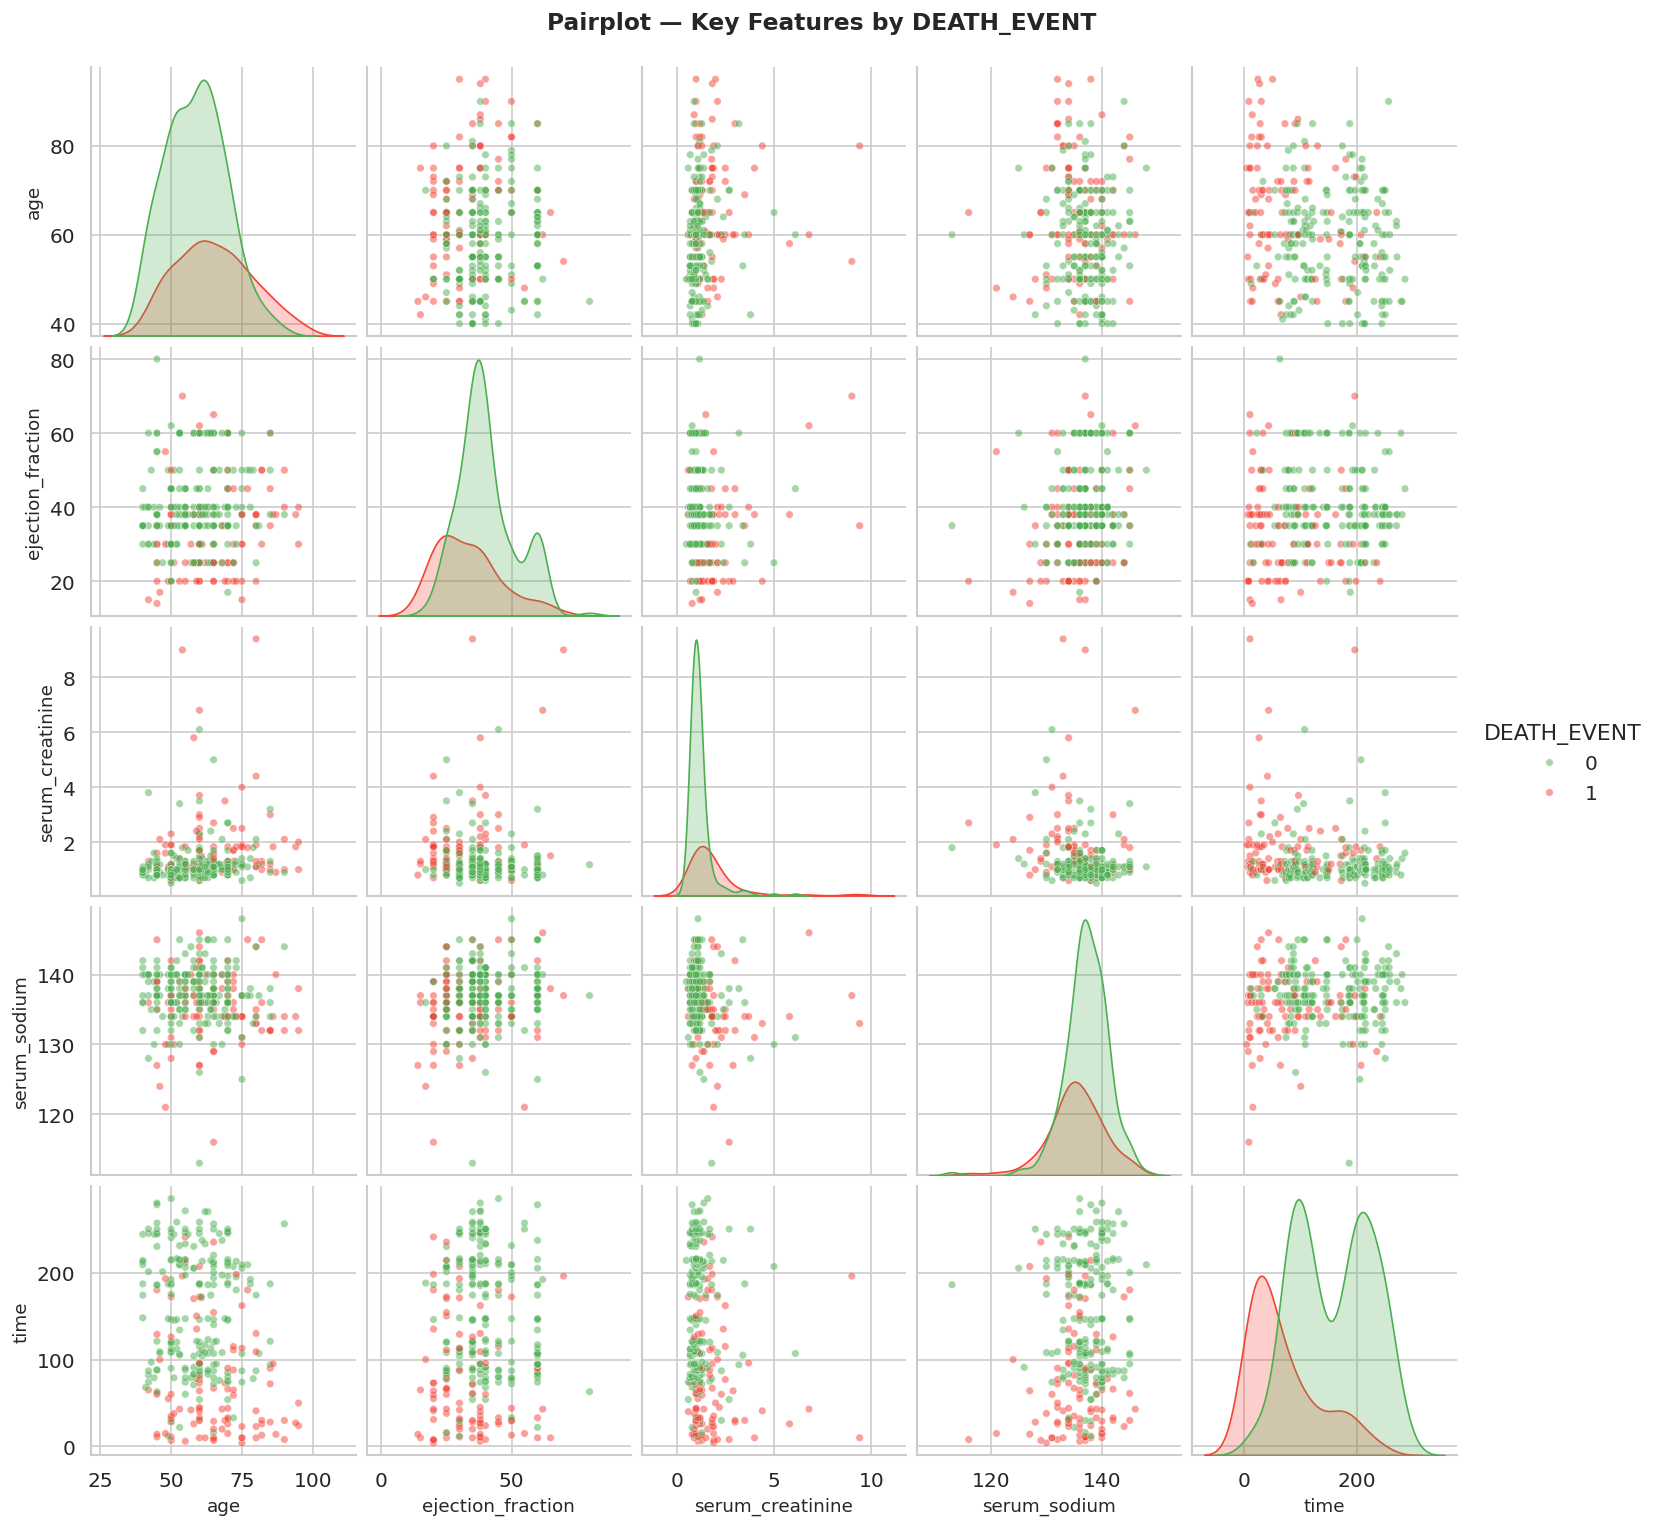

In [15]:
key_features = ['age', 'ejection_fraction', 'serum_creatinine',
                'serum_sodium', 'time', 'DEATH_EVENT']

g = sns.pairplot(df[key_features], hue='DEATH_EVENT',
                 palette={0: '#4CAF50', 1: '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20},
                 diag_kws={'fill': True})
g.figure.suptitle('Pairplot — Key Features by DEATH_EVENT',
                  y=1.02, fontsize=14, fontweight='bold')

# Rename legend
handles = g.legend.legend_handles
g.legend.set_title('DEATH_EVENT')
for handle, label in zip(handles, ['Survived', 'Deceased']):
    handle.set_label(label)
g.legend.set_texts = ['Survived', 'Deceased']

plt.show()

## 12 · Statistical Summary by Group

In [16]:
summary = df.groupby('DEATH_EVENT')[continuous_cols].agg(['mean', 'median', 'std']).round(2)
summary.index = ['Survived', 'Deceased']
summary

age               creatinine_phosphokinase                  \
           mean median    std                     mean median      std   
Survived  58.76   60.0  10.64                   540.05  245.0   753.80   
Deceased  65.22   65.0  13.21                   670.20  259.0  1316.58   

         ejection_fraction                platelets  ...            \
                      mean median    std       mean  ...       std   
Survived             40.27   38.0  10.86  266657.49  ...  97531.20   
Deceased             33.47   30.0  12.53  256381.04  ...  98525.68   

         serum_creatinine              serum_sodium                 time  \
                     mean median   std         mean median   std    mean   
Survived             1.18    1.0  0.65       137.22  137.0  3.98  158.34   
Deceased             1.84    1.3  1.47       135.38  135.5  5.00   70.89   

                        
         median    std  
Survived  172.0  67.74  
Deceased   44.5  62.38  

[2 rows x 21 columns]

In [17]:
# Mann-Whitney U test for each continuous feature
print('── Mann-Whitney U Test (Survived vs Deceased) ──\n')
print(f'{"Feature":<32} {"p-value":>10}  Significant (α=0.05)?')
print('-' * 60)
survived = df[df['DEATH_EVENT'] == 0]
deceased  = df[df['DEATH_EVENT'] == 1]
for col in continuous_cols:
    stat, p = stats.mannwhitneyu(survived[col], deceased[col],
                                  alternative='two-sided')
    sig = '✔ YES' if p < 0.05 else '✘ NO'
    print(f'{col:<32} {p:>10.4f}  {sig}')

── Mann-Whitney U Test (Survived vs Deceased) ──

Feature                             p-value  Significant (α=0.05)?
------------------------------------------------------------
age                                  0.0002  ✔ YES
creatinine_phosphokinase             0.6840  ✘ NO
ejection_fraction                    0.0000  ✔ YES
platelets                            0.4256  ✘ NO
serum_creatinine                     0.0000  ✔ YES
serum_sodium                         0.0003  ✔ YES
time                                 0.0000  ✔ YES


## 13 · Age Distribution by Sex and DEATH_EVENT

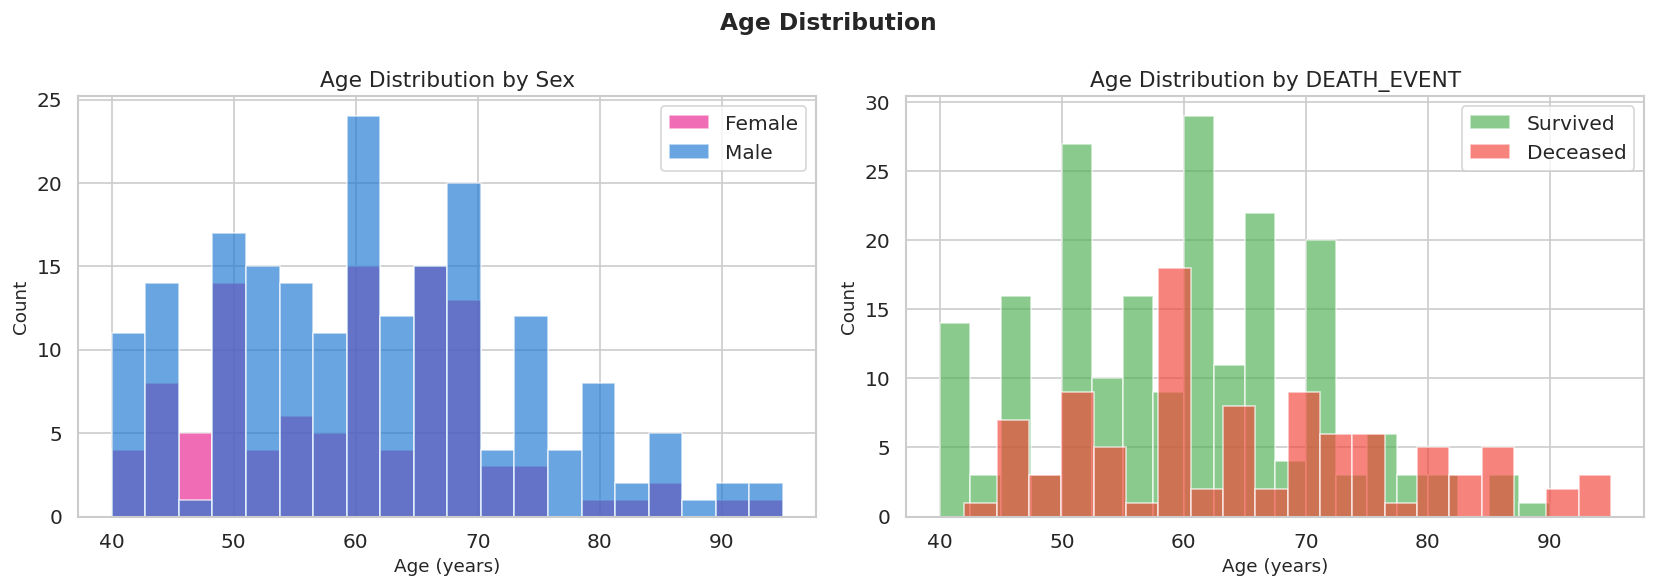

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by Sex
for sex_val, label, color in [(0, 'Female', '#E91E8C'), (1, 'Male', '#1976D2')]:
    axes[0].hist(df[df['sex'] == sex_val]['age'], bins=20,
                 alpha=0.65, color=color, edgecolor='white', label=label)
axes[0].set_title('Age Distribution by Sex')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Age by DEATH_EVENT
for de_val, label, color in [(0, 'Survived', '#4CAF50'), (1, 'Deceased', '#F44336')]:
    axes[1].hist(df[df['DEATH_EVENT'] == de_val]['age'], bins=20,
                 alpha=0.65, color=color, edgecolor='white', label=label)
axes[1].set_title('Age Distribution by DEATH_EVENT')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Age Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14 · Key Insights Summary

In [19]:
print('=' * 60)
print('   EDA — KEY INSIGHTS SUMMARY')
print('=' * 60)
print(f"""
Dataset   : {len(df)} patients, 13 features, no missing values
Class Split: Survived={counts[0]} ({counts[0]/len(df)*100:.1f}%)  """
      f"Deceased={counts[1]} ({counts[1]/len(df)*100:.1f}%)\n"
"""
Top correlated features with DEATH_EVENT:
  • time               (−0.53) — Longer follow-up → better survival
  • serum_creatinine   (+0.29) — Higher creatinine → worse prognosis
  • ejection_fraction  (−0.27) — Higher EF → better survival
  • age                (+0.25) — Older patients → higher mortality

Statistical significance (Mann-Whitney U, α=0.05):
  Significant  : age, ejection_fraction, serum_creatinine,
                 serum_sodium, time
  Not significant: creatinine_phosphokinase, platelets

Class Imbalance: ~67% survived vs ~33% deceased → moderate imbalance
""")

   EDA — KEY INSIGHTS SUMMARY

Dataset   : 299 patients, 13 features, no missing values
Class Split: Survived=203 (67.9%)  Deceased=96 (32.1%)

Top correlated features with DEATH_EVENT:
  • time               (−0.53) — Longer follow-up → better survival
  • serum_creatinine   (+0.29) — Higher creatinine → worse prognosis
  • ejection_fraction  (−0.27) — Higher EF → better survival
  • age                (+0.25) — Older patients → higher mortality

Statistical significance (Mann-Whitney U, α=0.05):
  Significant  : age, ejection_fraction, serum_creatinine,
                 serum_sodium, time
  Not significant: creatinine_phosphokinase, platelets

Class Imbalance: ~67% survived vs ~33% deceased → moderate imbalance

